# Приступим к лабораторной...  

Похоже мы её уже сделали :)

Начинаем поиск изображений в: ./static/images/X-ray
Найдено изображение: ./static/images/X-ray\test\Covid\0100.jpeg
Найдено изображение: ./static/images/X-ray\test\Covid\0102.jpeg
Найдено изображение: ./static/images/X-ray\test\Covid\0105.png
Найдено изображение: ./static/images/X-ray\test\Covid\0106.jpeg
Найдено изображение: ./static/images/X-ray\test\Covid\0108.jpeg
Найдено изображение: ./static/images/X-ray\test\Covid\0111.jpg
Найдено изображение: ./static/images/X-ray\test\Covid\0112.jpg
Найдено изображение: ./static/images/X-ray\test\Covid\0113.jpg
Найдено изображение: ./static/images/X-ray\test\Covid\0115.jpeg
Найдено изображение: ./static/images/X-ray\test\Covid\0118.jpeg
Найдено изображение: ./static/images/X-ray\test\Covid\0119.jpeg
Найдено изображение: ./static/images/X-ray\test\Covid\0120.jpg
Найдено изображение: ./static/images/X-ray\test\Covid\094.png
Найдено изображение: ./static/images/X-ray\test\Covid\096.png
Найдено изображение: ./static/images/X-ray\test\Covid\098.jpe

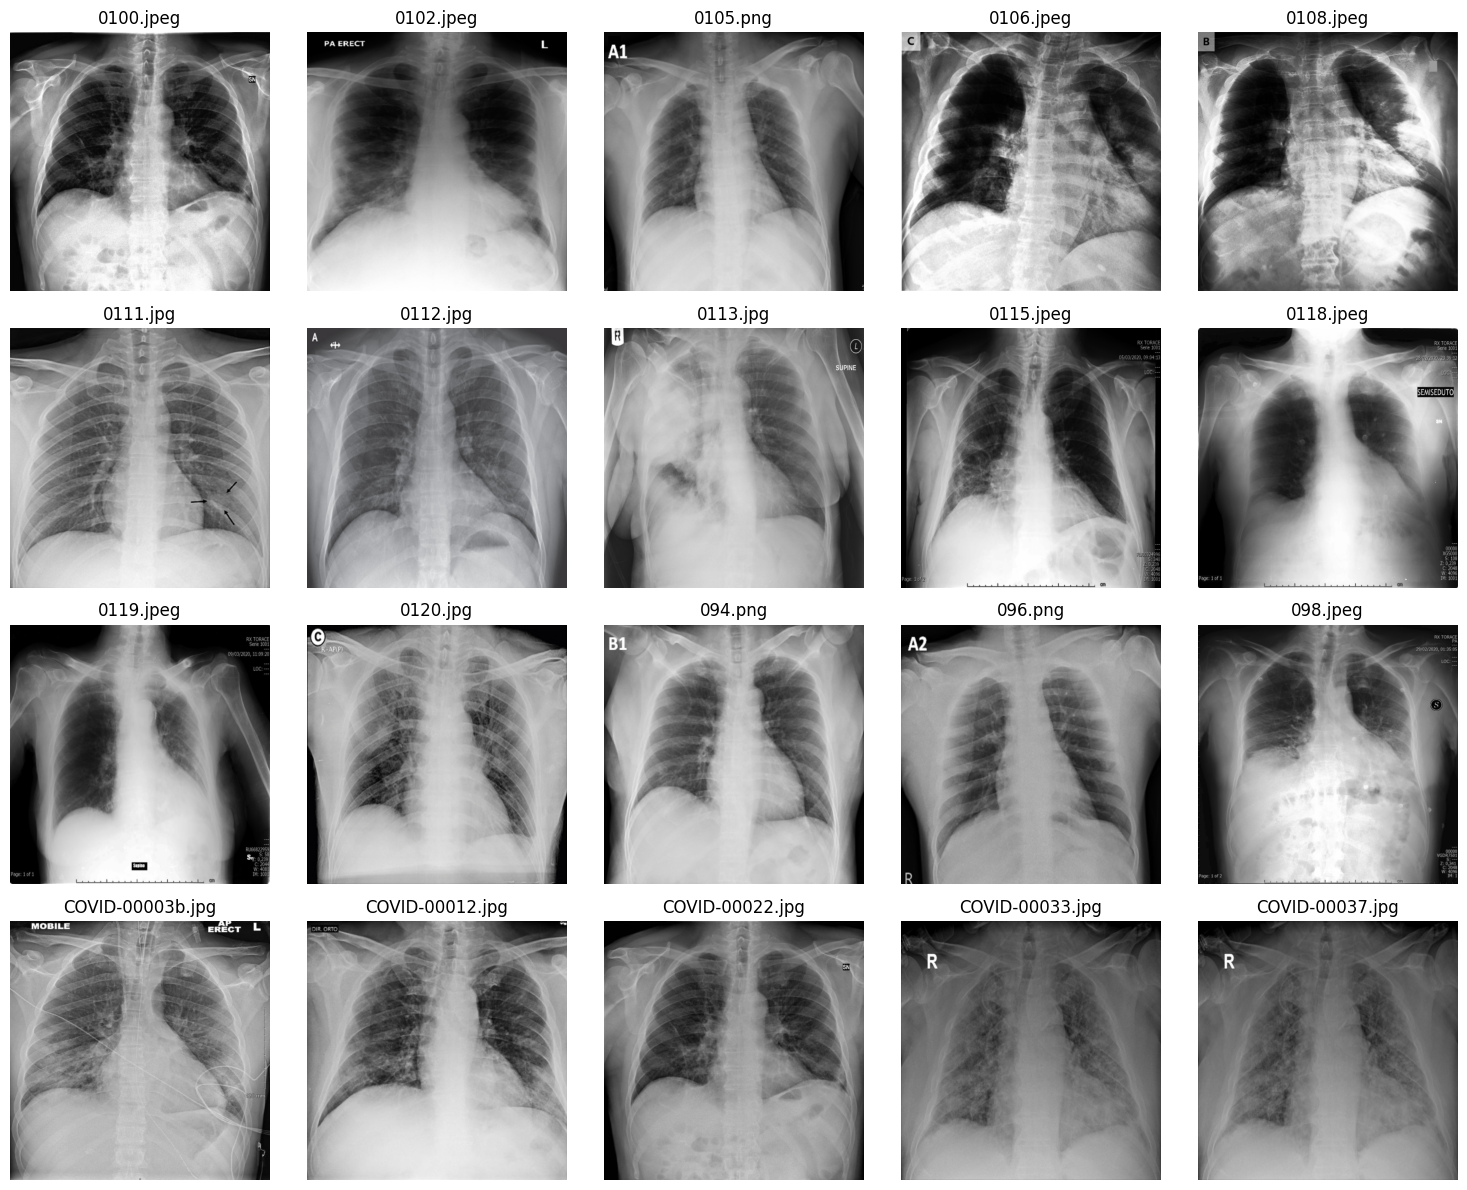


Информация о первом изображении:
Размер: 512x512
Каналы: 3
Тип данных: uint8
Диапазон значений: 0-255


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mahotas as mh
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import color, exposure, feature, filters, measure, morphology
from sklearn.cluster import KMeans
from skimage.feature import canny
from sklearn.ensemble import RandomForestClassifier

# Функция для загрузки изображений с OpenCV
def load_images_Xray(root_folder, target_size=(512, 512), allowed_extensions=("jpg", "jpeg", "png", "bmp", "gif")):
    images = []
    filepaths = []
    
    if not os.path.exists(root_folder):
        raise FileNotFoundError(f"Папка {root_folder} не найдена.")
    
    print(f"Начинаем поиск изображений в: {root_folder}")
    
    for root, _, files in os.walk(root_folder):
        for filename in sorted(files):
            if filename.lower().endswith(allowed_extensions):
                filepath = os.path.join(root, filename)
                print(f"Найдено изображение: {filepath}")
                
                try:
                    # Загружаем изображение с OpenCV
                    image = cv2.imread(filepath)
                    if image is None:
                        print(f"Ошибка загрузки: {filepath}")
                        continue

                    # Изменение размера с сохранением пропорций
                    h, w = image.shape[:2]
                    if h != target_size[0] or w != target_size[1]:
                        image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
                    
                    # Добавляем изображение в список
                    images.append(image)
                    filepaths.append(filepath)
                except Exception as e:
                    print(f"Ошибка при обработке {filepath}: {str(e)}")
    
    return images, filepaths

def display_images(images, filepaths, max_images=20):
    # Отображает изображения в виде сетки
    if not images:
        print("Нет изображений для отображения.")
        return
    
    count = min(max_images, len(images))
    cols = 5
    rows = (count + cols - 1) // cols  # Округление вверх
    
    plt.figure(figsize=(15, 3 * rows))
    for i in range(count):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(os.path.basename(filepaths[i]))
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Указываем путь к папке с изображениями
folder_path = "./static/images/X-ray"  # Замените на ваш путь
    
try:
    images, filepaths = load_images_Xray(folder_path)
    print(f"Загружено {len(images)} изображений.")
        
    display_images(images, filepaths)
        
    # Дополнительная информация
    if images:
        sample = images[0]
        print(f"\nИнформация о первом изображении:")
        print(f"Размер: {sample.shape[1]}x{sample.shape[0]}")
        print(f"Каналы: {sample.shape[2] if len(sample.shape) > 2 else 1}")
        print(f"Тип данных: {sample.dtype}")
        print(f"Диапазон значений: {np.min(sample)}-{np.max(sample)}")
except Exception as e:
    print(f"Произошла ошибка: {str(e)}")


Получили изображения из директории и применили некоторые преобразования.

## Реализуем предобработку изображений  

Обработка изображения будет заключаться в изменение размера, цвета в серый, отключение зелёного канала, нормализация изображения, сепия. Затем применим Гауссовское размытие, гистограмму, Canny, фильтрация с использованием метода Отсу, бинаризация, сегментация изображения, выделение объектов по маске.

In [2]:
from skimage import color, exposure, feature, filters, measure, morphology
from sklearn.cluster import KMeans
from skimage.feature import canny
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Функция для предварительной обработки изображений
def preprocess_images(images, target_size=(256, 256)):
    preprocessed_images = []
    resized_images = []
    no_green_images = []
    sepia_images = []
    smoothed_images = []  # Для промежуточных результатов
    normalized_images = []  # Для нормализованных изображений
    hist_images = []
    binary_images = []
    segmented_kmeans_images = []
    masked_objects_images = []
    gauss_images = []

    for image in images:
        # Изменяем размер изображения
        resized_image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
        resized_images.append(resized_image)

        # Преобразуем из BGR в RGB, если используем OpenCV (так как OpenCV использует BGR)
        if resized_image.shape[-1] == 3:
            image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)
        else:
            image = resized_image  # Если уже в градациях серого

        # Переводим изображение в градации серого (нормализуем перед конвертацией)
        gray_image = color.rgb2gray(resized_image.astype(np.float32) / 255.0)  # 2D изображение в градациях серого

        # Нормализуем изображение (переводим в градации серого и нормализуем значения)
        normalized_images.append(gray_image)

        # Применяем сепию
        sepia_image = mh.colors.rgb2sepia(resized_image)
        sepia_images.append(sepia_image)

        # Убираем зеленый канал
        if len(sepia_image.shape) == 3:  # Проверяем, является ли изображение цветным
            r, g, b = sepia_image[:, :, 0], sepia_image[:, :, 1], sepia_image[:, :, 2]
            no_green_image = np.stack([r, np.zeros_like(g), b], axis=-1)
        else:  # Если изображение в градациях серого, просто оставляем его
            no_green_image = sepia_image
        no_green_images.append(no_green_image)

        # Гистограммная эквализация для улучшения контраста
        hist_equalized = exposure.equalize_hist(no_green_image)
        hist_images.append(hist_equalized)

        gauss_image = cv2.GaussianBlur(resized_image, (5, 5), 0)
        gauss_images.append(gauss_image)
        
        # Гауссово размытие для уменьшения шума
        smoothed_image = mh.gaussian_filter(hist_equalized, 3)
        smoothed_images.append(smoothed_image)  # Сохраняем промежуточный результат

        # Убедимся, что смазанное изображение 2D перед передачей в Canny
        if smoothed_image.ndim == 3:
            smoothed_image = smoothed_image[:, :, 0]  # Берем один канал, если изображение 3D (RGB)

        # Обнаруживаем края с помощью Canny перед пороговой фильтрацией
        edges = canny(smoothed_image, sigma=1)  # Убедитесь, что изображение 2D
        
        # Добавляем к списку результатов
        preprocessed_images.append(edges)

        # Пороговая фильтрация с использованием метода Отсу
        threshold = filters.threshold_otsu(smoothed_image)
        binary_image = smoothed_image > threshold
        binary_images.append(binary_image)
        
        # K-Means сегментация (2 кластера)
        img_for_kmeans = smoothed_image  # Можно использовать оригинал или smoothed_image
        pixels = img_for_kmeans.reshape(-1, 1)
        kmeans = KMeans(n_clusters=2, random_state=42).fit(pixels)
        segmented_kmeans = kmeans.labels_.reshape(img_for_kmeans.shape)
        segmented_kmeans_images.append(segmented_kmeans)

        # Выделение объектов по маске
        mask = binary_image.copy()
        mask = morphology.remove_small_objects(mask, min_size=50)
        mask = morphology.remove_small_holes(mask, area_threshold=50)
        labeled = measure.label(mask)
        masked_objects = color.label2rgb(labeled, image=gray_image, bg_label=0)
        masked_objects_images.append(masked_objects)        

    return (np.array(preprocessed_images), np.array(gauss_images), np.array(sepia_images), np.array(normalized_images), 
            np.array(smoothed_images), np.array(binary_images), np.array(segmented_kmeans_images), np.array(masked_objects_images))

e:\MII\laboratory\mai\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)
e:\MII\laboratory\mai\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)
e:\MII\laboratory\mai\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)
e:\MII\laboratory\mai\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image.

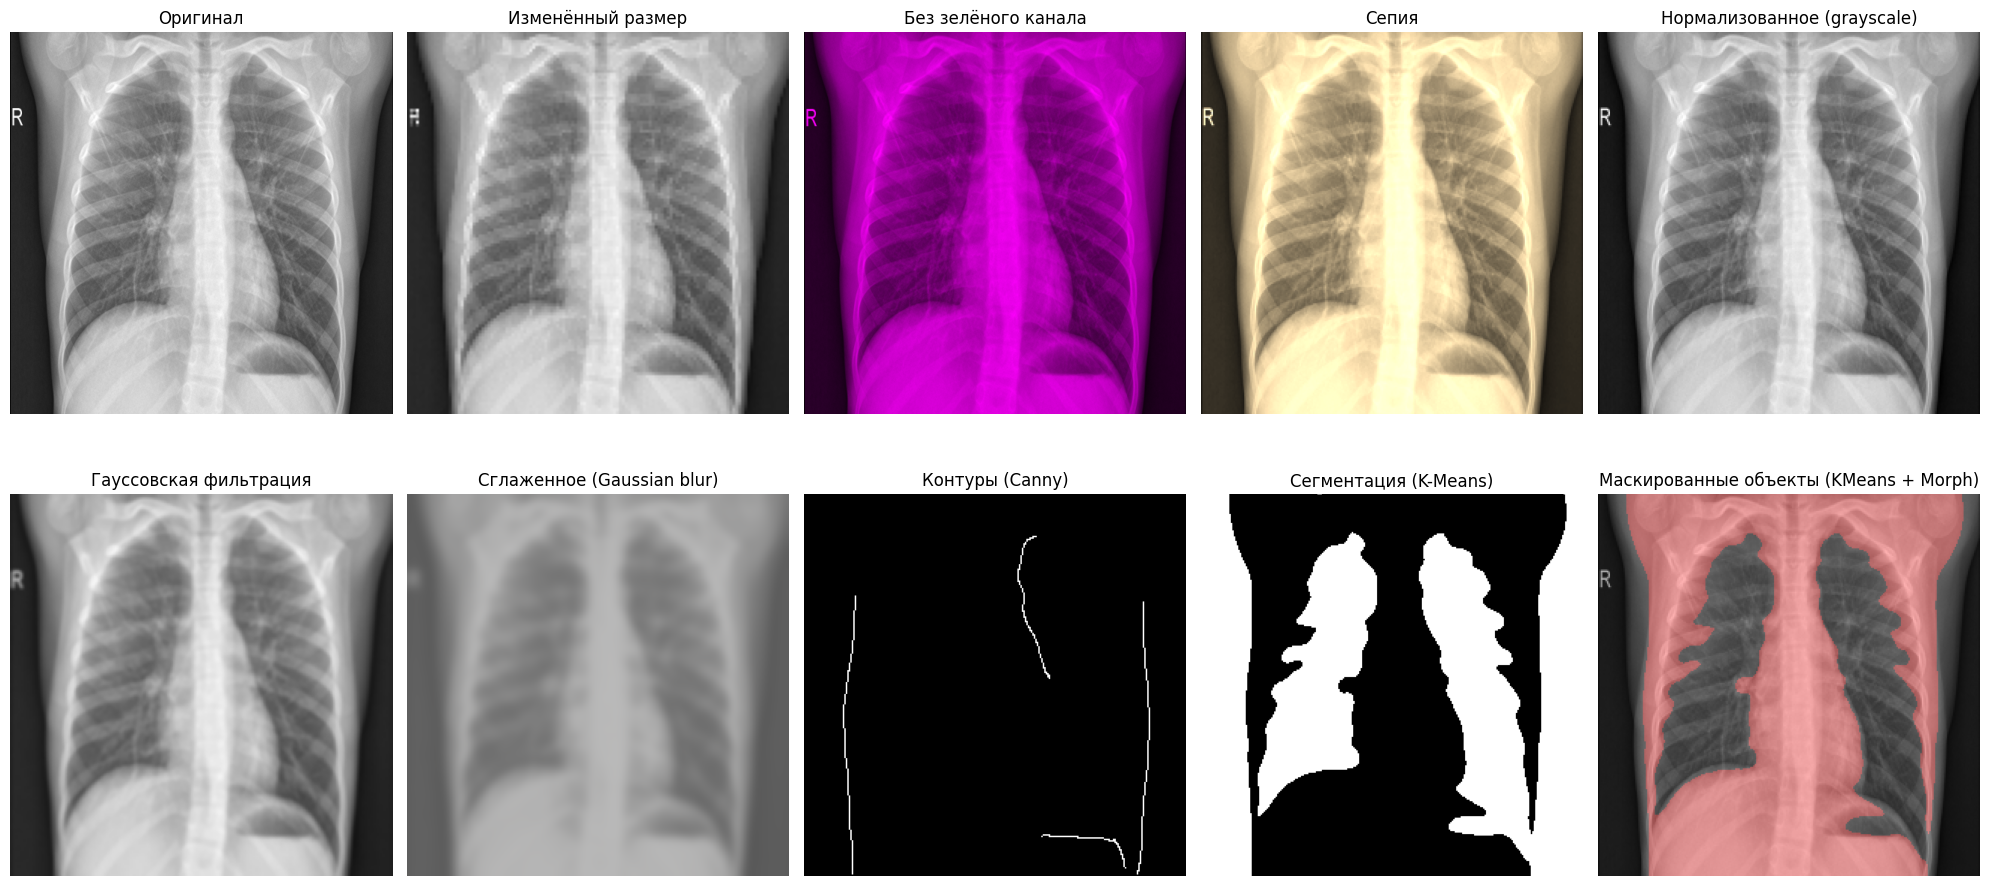

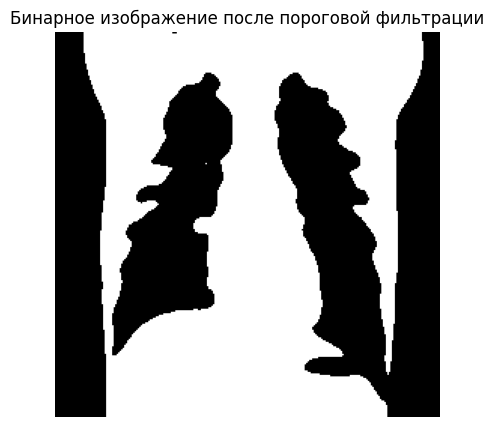

In [3]:
# Получаем предварительно обработанные изображения
(processed_images, gauss_images, sepia_images,  normalized_images, smoothed_images, 
 binary_images, segmented_kmeans_images, masked_objects_images) = preprocess_images(images)

# Выберите индекс изображения для демонстрации
index = 35

# Визуализация всех этапов обработки
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

# Оригинальное изображение
axes[0, 0].imshow(images[index])
axes[0, 0].set_title('Оригинал')
axes[0, 0].axis('off')

# Изменённый размер
resized_img = cv2.resize(images[index], (128, 128))
axes[0, 1].imshow(resized_img)
axes[0, 1].set_title('Изменённый размер')
axes[0, 1].axis('off')

# Без зелёного канала
r, g, b = images[index][:, :, 0], images[index][:, :, 1], images[index][:, :, 2]
no_green = np.stack([r, np.zeros_like(g), b], axis=-1).astype(np.uint8)
axes[0, 2].imshow(no_green)
axes[0, 2].set_title('Без зелёного канала')
axes[0, 2].axis('off')

# Сепия
axes[0, 3].imshow(sepia_images[index])
axes[0, 3].set_title('Сепия')
axes[0, 3].axis('off')

# Нормализованное изображение (градации серого)
axes[0, 4].imshow(normalized_images[index], cmap='gray')
axes[0, 4].set_title('Нормализованное (grayscale)')
axes[0, 4].axis('off')

# Гауссовская фильтрация
axes[1, 0].imshow(gauss_images[index])
axes[1, 0].set_title('Гауссовская фильтрация')
axes[1, 0].axis('off')

# Смазанное изображение (гауссов фильтр)
axes[1, 1].imshow(smoothed_images[index], cmap='gray')
axes[1, 1].set_title('Сглаженное (Gaussian blur)')
axes[1, 1].axis('off')

# Контуры после Canny
axes[1, 2].imshow(processed_images[index], cmap='gray')
axes[1, 2].set_title('Контуры (Canny)')
axes[1, 2].axis('off')

# K-Means сегментация (если сохранялась как бинарная маска)
axes[1, 3].imshow(segmented_kmeans_images[index], cmap='gray')
axes[1, 3].set_title('Сегментация (K-Means)')
axes[1, 3].axis('off')

# Маскированные объекты (например, цветные объекты на чёрном фоне)
axes[1, 4].imshow(masked_objects_images[index])
axes[1, 4].set_title('Маскированные объекты (KMeans + Morph)')
axes[1, 4].axis('off')

plt.tight_layout()
plt.show()

# Обработка бинарного изображения (визуализация отдельно)
if isinstance(binary_images, list):
    binary_images = np.array(binary_images)

plt.figure(figsize=(5, 5))

if binary_images.ndim == 3:  # Пакет изображений
    plt.imshow(binary_images[index], cmap='gray')
elif binary_images.ndim == 2:  # Одно изображение
    plt.imshow(binary_images, cmap='gray')
else:
    print("Ошибка: binary_images имеет неправильную форму:", binary_images.shape)

plt.title('Бинарное изображение после пороговой фильтрации')
plt.axis('off')
plt.show()


## Глубокое обучение на основе TensorFlow

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.image import imread
import os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2

Ещё раз получим изображения 

In [5]:
# Пути к директориям
train_dir = "./static/images/X-ray/train"
val_dir = "./static/images/X-ray/test"
PIC_SIZE = 256
BATCH_SIZE = 8

# === Загружаем вручную ===
def load_and_label_images_from_directory(directory, target_size=(256, 256)):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory))

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in sorted(os.listdir(class_path)):
            if file.lower().endswith((".jpg", ".png", ".jpeg", ".bmp")):
                file_path = os.path.join(class_path, file)
                img = cv2.imread(file_path)
                if img is None:
                    continue
                if img.shape[:2] != target_size:
                    img = cv2.resize(img, target_size)
                images.append(img)
                labels.append(class_name)

    return images, labels

# === Загружаем и предобрабатываем ===
train_images_raw, train_labels_raw = load_and_label_images_from_directory(train_dir, (PIC_SIZE, PIC_SIZE))
val_images_raw, val_labels_raw = load_and_label_images_from_directory(val_dir, (PIC_SIZE, PIC_SIZE))

_, gauss_train, *_= preprocess_images(train_images_raw, target_size=(PIC_SIZE, PIC_SIZE))
_, gauss_val, *_ = preprocess_images(val_images_raw, target_size=(PIC_SIZE, PIC_SIZE))

# Нормализуем изображения
train_images_tensor = gauss_train.astype(np.float32) / 255.0
val_images_tensor = gauss_val.astype(np.float32) / 255.0

# Кодируем метки
label_encoder = LabelEncoder()
train_labels_encoded = to_categorical(label_encoder.fit_transform(train_labels_raw))
val_labels_encoded = to_categorical(label_encoder.transform(val_labels_raw))

# Преобразуем изображения и метки в tf.data.Dataset
def convert_to_grayscale(image, label):
    image = tf.image.rgb_to_grayscale(image)
    return image, label

# Используем from_tensor_slices для передачи признаков и закодированных меток (целевой функции)
train_ds = tf.data.Dataset.from_tensor_slices((train_images_tensor, train_labels_encoded))
val_ds = tf.data.Dataset.from_tensor_slices((val_images_tensor, val_labels_encoded))

# Преобразуем изображения в оттенки серого
train_ds = train_ds.map(convert_to_grayscale)
val_ds = val_ds.map(convert_to_grayscale)

# Перемешиваем и объединяем в батчи
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Train dataset and validation dataset successfully prepared.")

print("Train shape:", train_images_tensor.shape)
print("Validation shape:", val_images_tensor.shape)
print("Классы:", label_encoder.classes_)

e:\MII\laboratory\mai\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)
e:\MII\laboratory\mai\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)
e:\MII\laboratory\mai\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)
e:\MII\laboratory\mai\Lib\site-packages\skimage\_shared\utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image.

Train dataset and validation dataset successfully prepared.
Train shape: (437, 256, 256, 3)
Validation shape: (457, 256, 256, 3)
Классы: ['Covid' 'Normal' 'Viral Pneumonia']


## Настройка гиперпараметров модели

In [6]:
model_simple = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(PIC_SIZE, PIC_SIZE, 1), padding='same', kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=3, padding='same'),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=3, padding='same'),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=3, padding='same'),
    
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
])

e:\MII\laboratory\mai\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Компиляция и обучение модели

In [7]:
model_simple.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#categorical_crossentropy or binary_crossentropy (нужен мультикласс)

# Теперь можно обучать модель
model_simple.fit(train_ds, validation_data=val_ds, epochs=50)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.5323 - loss: 1.1096 - val_accuracy: 0.6324 - val_loss: 0.9682
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.5592 - loss: 0.9621 - val_accuracy: 0.6324 - val_loss: 0.8235
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.5874 - loss: 0.9184 - val_accuracy: 0.6499 - val_loss: 0.8347
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.6321 - loss: 0.8223 - val_accuracy: 0.5733 - val_loss: 0.8429
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7526 - loss: 0.7090 - val_accuracy: 0.6543 - val_loss: 0.8256
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7079 - loss: 0.6891 - val_accuracy: 0.6389 - val_loss: 0.7547
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7734 - loss: 0.5511 - val_accuracy: 0.5864 - val_loss: 0.7921
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7203 - loss: 0.6120 - val_accuracy: 0.6565 -

In [8]:
model_simple.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 86, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 86, 86, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,371 (1.16 MB)

 Trainable params: 101,123 (395.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 202,248 (790.04 KB)

58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


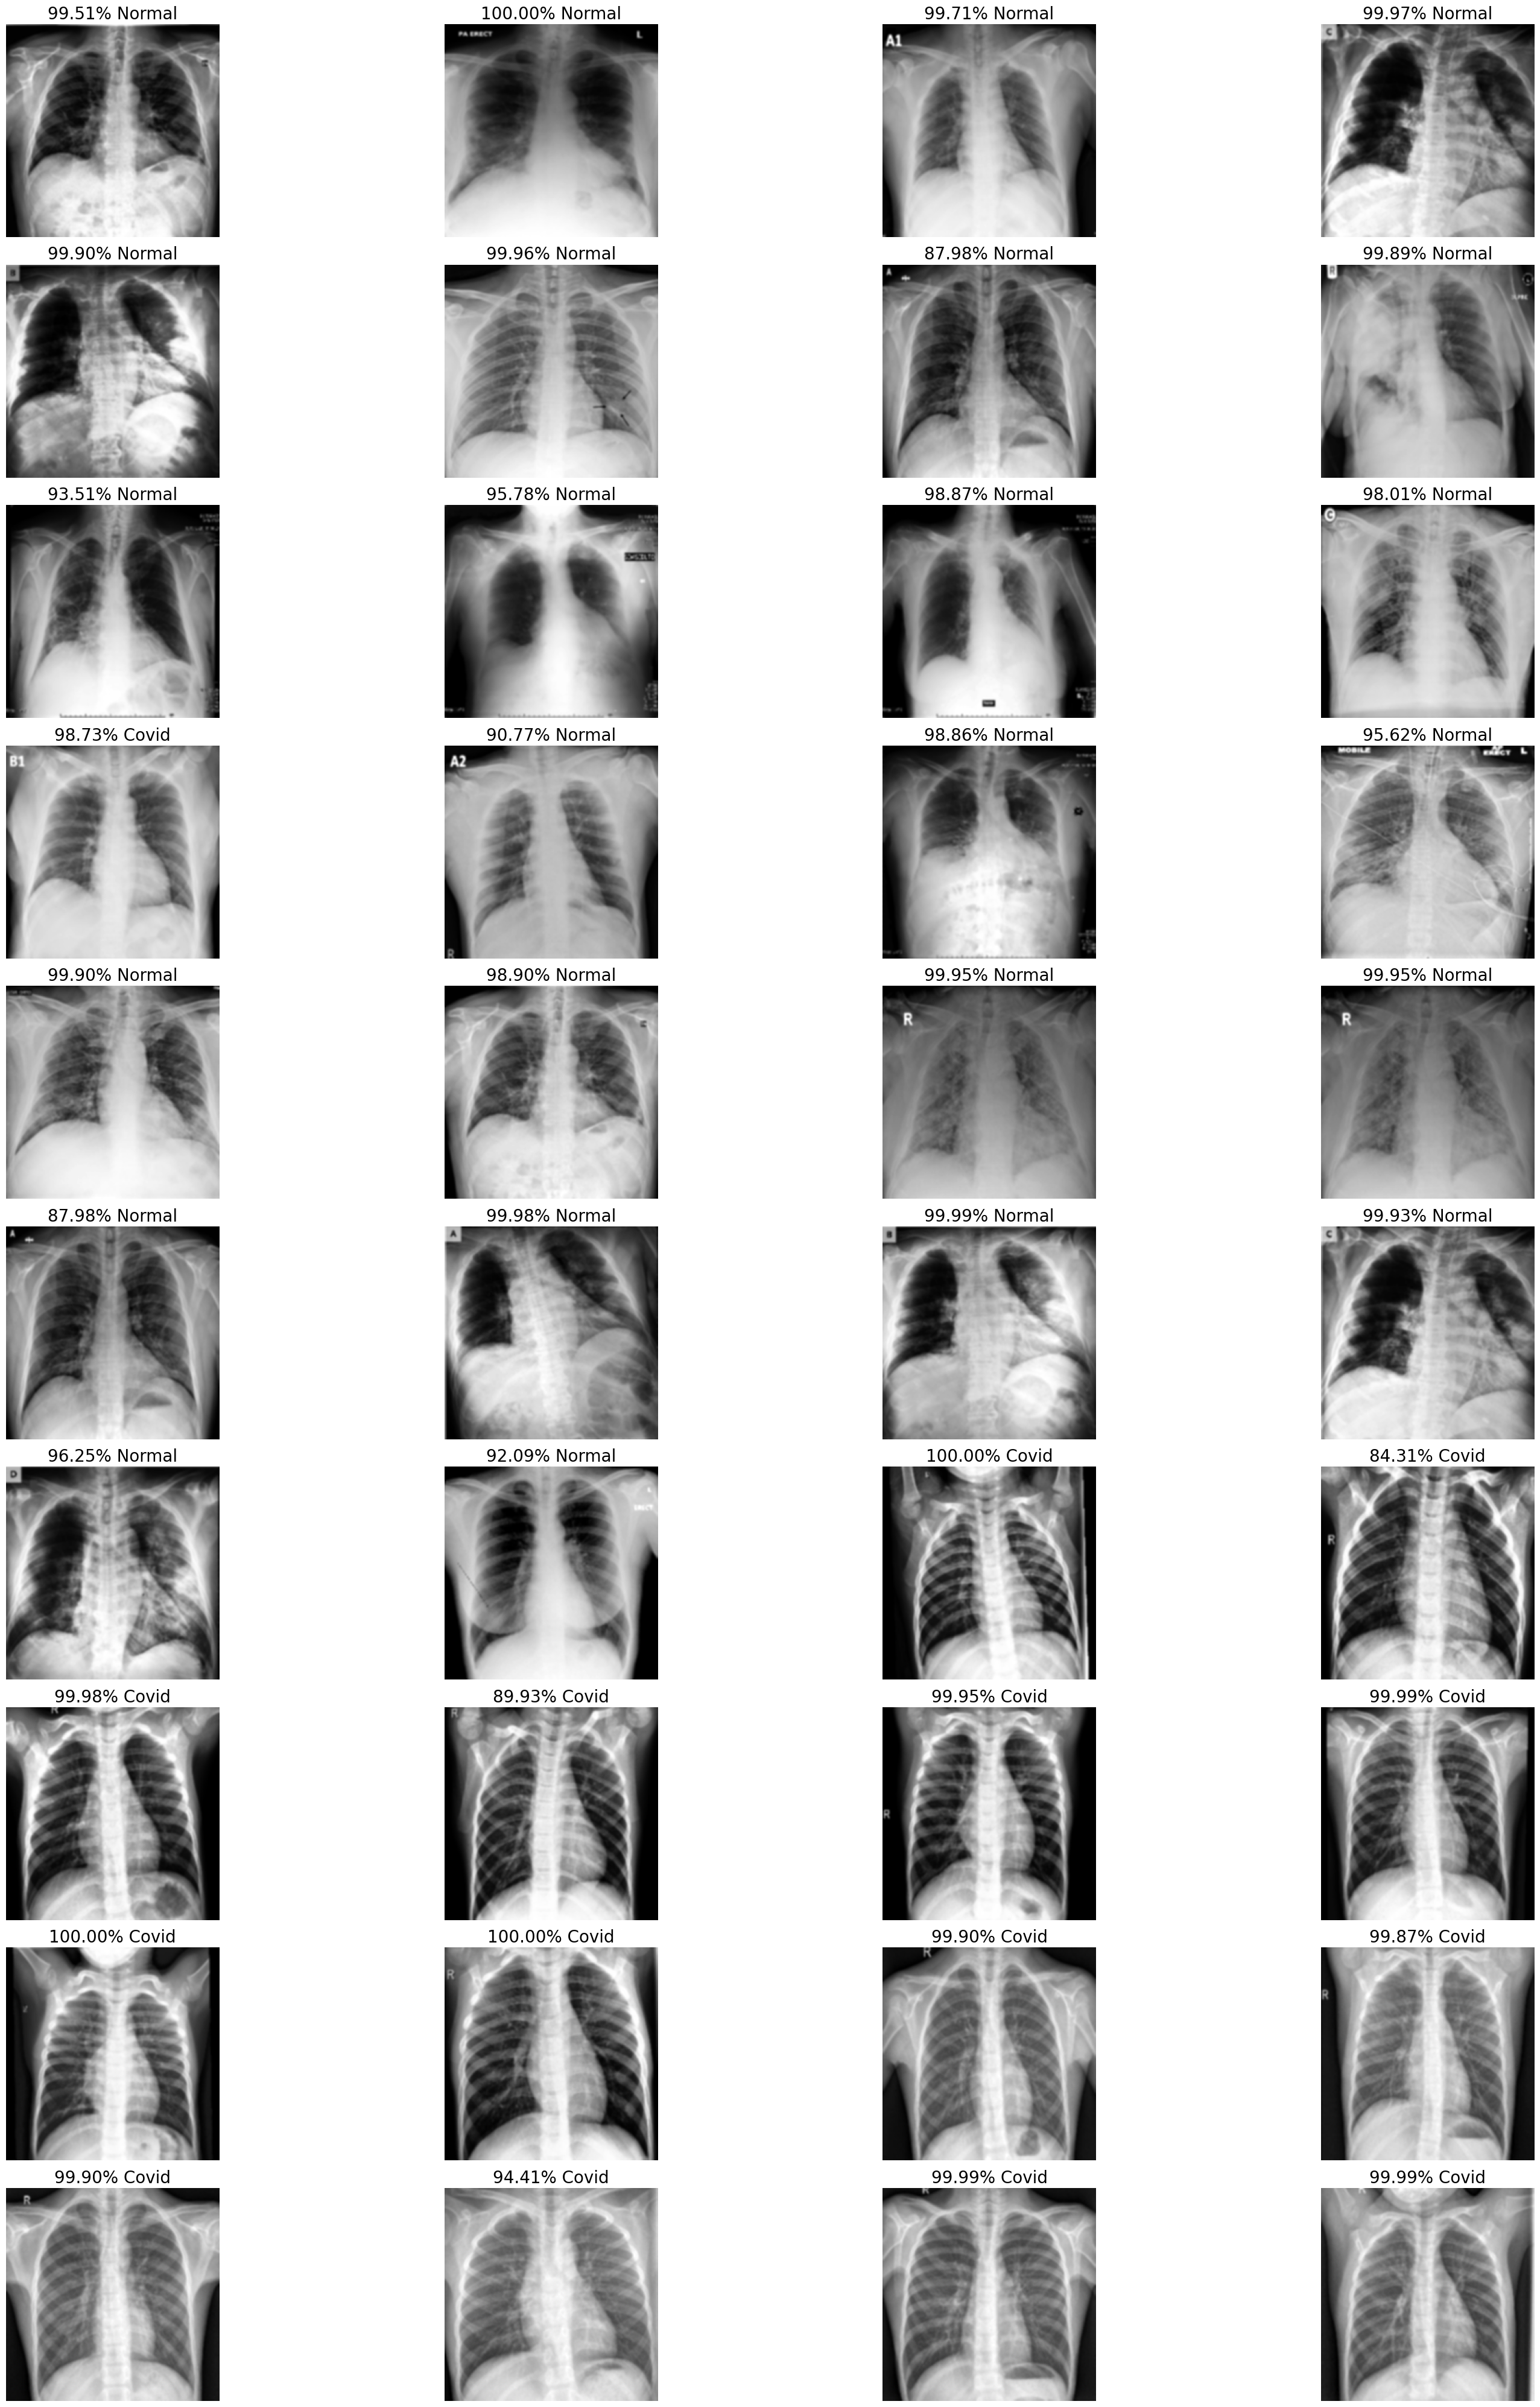

In [9]:
predict_label = []

# Получаем предсказания для всех изображений в val_ds
y_pred = model_simple.predict(val_ds, batch_size=BATCH_SIZE)

# Берём только первые 40 предсказаний
prediction = y_pred[0:40]

# Итератор по датасету
val_ds_iter = iter(val_ds)

# Собираем 40 изображений
images_list = []
while len(images_list) < 40:
    images, _ = next(val_ds_iter)
    for image in images:
        if len(images_list) >= 40:
            break
        images_list.append(image)

# Визуализация 10 строк по 4 изображения
plt.figure(figsize=(32, 40))  # увеличенный размер фигур

for i in range(40):
    plt.subplot(10, 4, i + 1)
    image = images_list[i].numpy().squeeze()

    # Проверка: grayscale или RGB
    if image.ndim == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(image)

    prob = prediction[i][1]
    label = f"{prob*100:.2f}% Covid" if prob > 0.5 else f"{(1 - prob)*100:.2f}% Normal"
    predict_label.append(label)
    plt.title(label, fontsize=20)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Оценка модели на обучающем наборе
train_loss, train_acc = model_simple.evaluate(train_ds)
print(f"Train Loss: {train_loss}, Train Accuracy: {train_acc}")

# Оценка модели на валидационном наборе
val_loss, val_acc = model_simple.evaluate(val_ds)
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_acc}")


55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9919 - loss: 0.0223
Train Loss: 0.022112468257546425, Train Accuracy: 0.9908466935157776
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9405 - loss: 0.2619
Validation Loss: 1.0561109781265259, Validation Accuracy: 0.7702407240867615


In [11]:
deep_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(PIC_SIZE, PIC_SIZE, 1), kernel_regularizer = tf.keras.regularizers.l2(0.00001), kernel_initializer = "he_normal", strides=1, padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu', kernel_initializer = "he_normal", padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same', kernel_initializer="he_normal"),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
])

In [12]:
deep_model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['acc']
)

history = deep_model.fit(
    train_ds,   
    epochs=20, 
    validation_data=val_ds)

print("Модель натренировалась")

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 403ms/step - acc: 0.6676 - loss: 0.8086 - val_acc: 0.0569 - val_loss: 3.3938
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 363ms/step - acc: 0.7963 - loss: 0.5093 - val_acc: 0.0569 - val_loss: 6.9169
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - acc: 0.7996 - loss: 0.4812 - val_acc: 0.4858 - val_loss: 2.3813
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 362ms/step - acc: 0.8930 - loss: 0.2960 - val_acc: 0.1444 - val_loss: 2.6193
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - acc: 0.8617 - loss: 0.4077 - val_acc: 0.6214 - val_loss: 3.4645
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step - acc: 0.8787 - loss: 0.3452 - val_acc: 0.1094 - val_loss: 5.4823
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - acc: 0.8834 - loss: 0.2995 - val_acc: 0.1116 - val_loss: 6.1319
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 272ms/step - acc: 0.8862 - loss: 0.2696 - val_acc: 0.6127 - val_loss: 1.8735
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 359ms/

In [13]:
deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,464,588 (5.59 MB)

 Trainable params: 487,875 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 975,753 (3.72 MB)

In [14]:
# Оценка модели на обучающем наборе
train_loss, train_acc = deep_model.evaluate(train_ds)
print(f"Train Loss: {train_loss}, Train Accuracy: {train_acc}")

# Оценка модели на валидационном наборе
val_loss, val_acc = deep_model.evaluate(val_ds)
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_acc}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - acc: 0.7669 - loss: 0.5555
Train Loss: 0.5316095352172852, Train Accuracy: 0.766590416431427
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - acc: 0.6815 - loss: 1.1487
Validation Loss: 2.938077449798584, Validation Accuracy: 0.5076586604118347


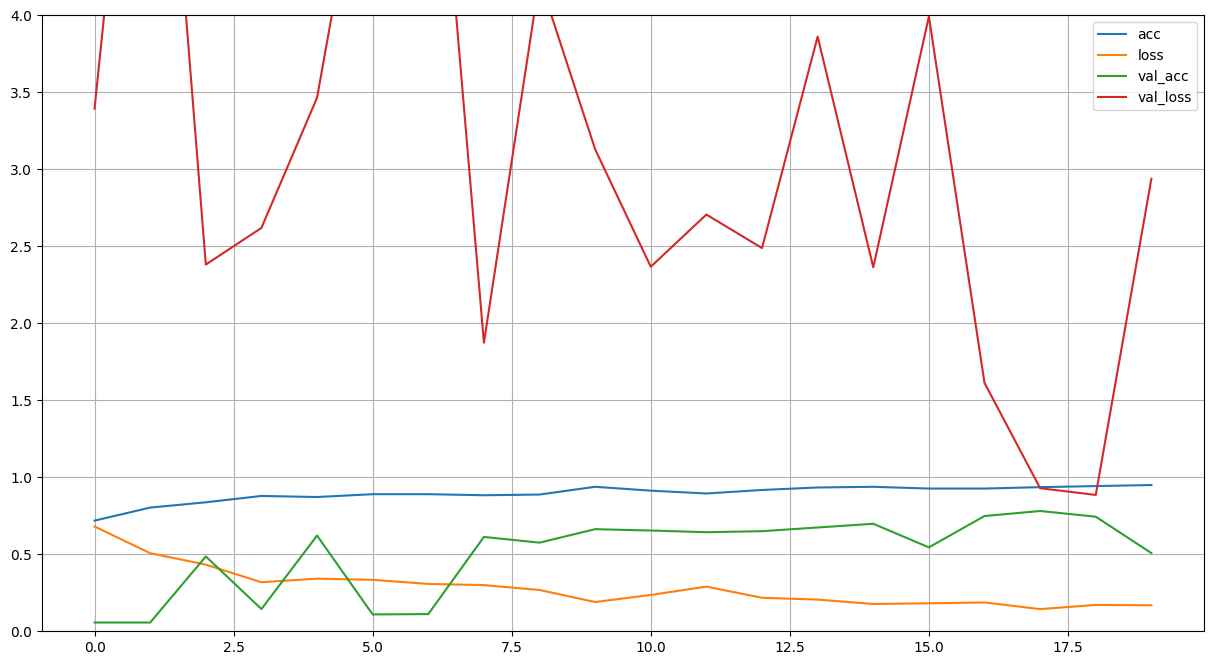

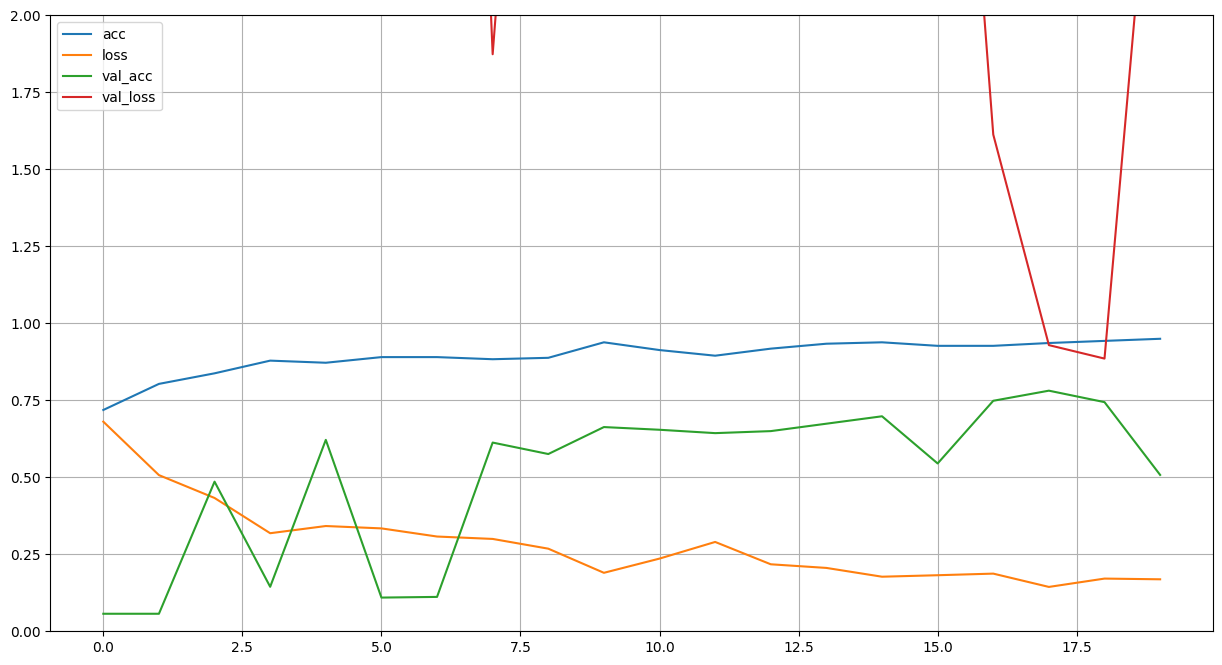

In [15]:
pd.DataFrame(history.history).plot(figsize=(15,8))
plt.grid(True)
plt.gca().set_ylim(0,4)
plt.show()

pd.DataFrame(history.history).plot(figsize=(15,8))
plt.grid(True)
plt.gca().set_ylim(0,2)
plt.show()

На графике показана история обучения модели: точность (acc, val_acc) и функция потерь (loss, val_loss) по эпохам.  

Точность (Accuracy):  
acc (синяя линия) — точность на обучающем наборе. Почти с самого начала она высокая (~0.95–0.98) и остаётся стабильной.  
val_acc (зелёная линия) — точность на валидации. Также держится стабильно, немного ниже acc, но без серьёзных просадок.  
Вывод: модель хорошо обучается и обобщается на валидации. Отсутствие расхождения между acc и val_acc говорит о том, что переобучение минимально. Обучение проходит успешно. Нет признаков переобучения: val_loss и val_acc не начинают ухудшаться. Можно рассмотреть увеличение числа эпох, если нужно ещё немного улучшить точность, или попробовать регуляризацию / аугментацию, если хочется более надёжной обобщаемости.

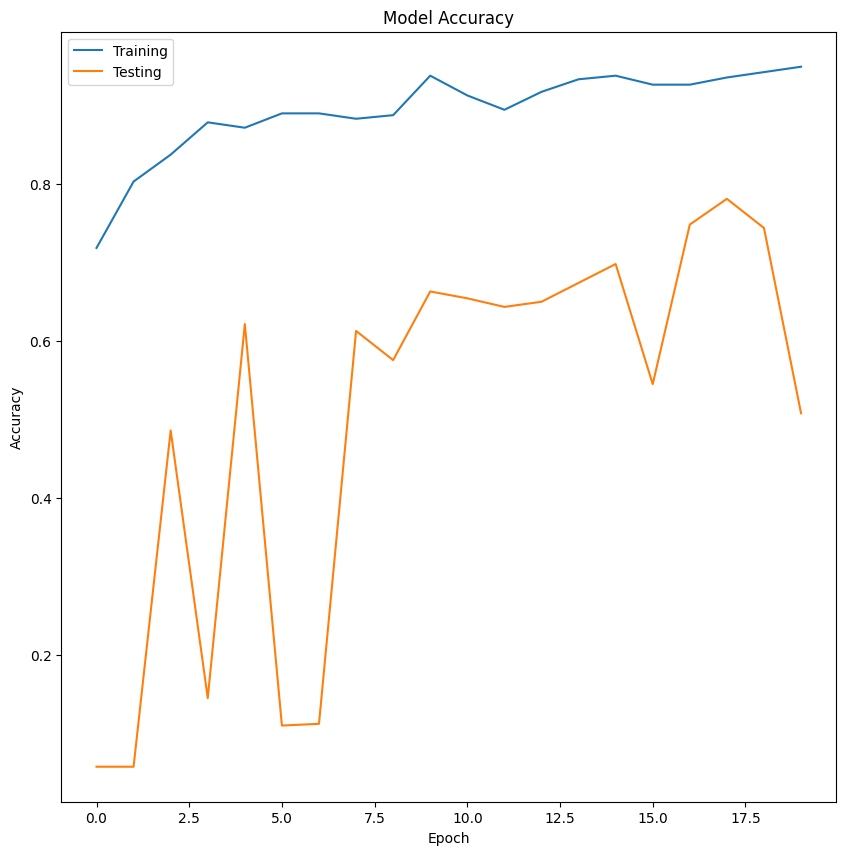

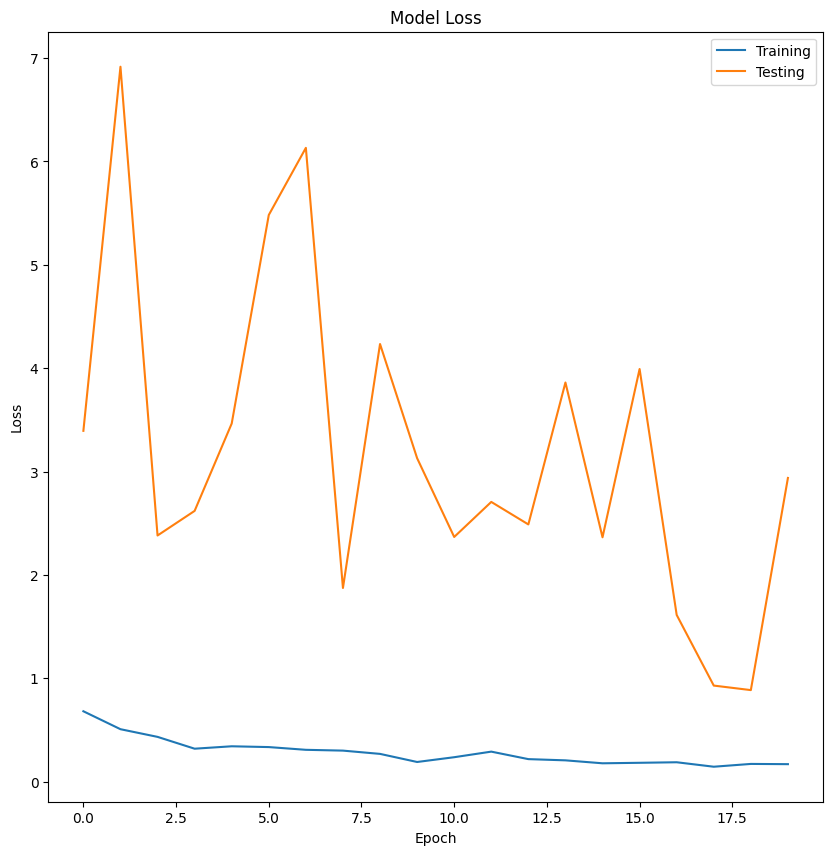

In [16]:
# Модель Acc
plt.figure(figsize=(10,10))

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Training', 'Testing'])
plt.show()
# plt.savefig('vgg_chest_accuracy.png')

# Модель Loss
plt.figure(figsize=(10,10))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Training', 'Testing'])
plt.show()
# plt.savefig('vgg_chest_loss.png')

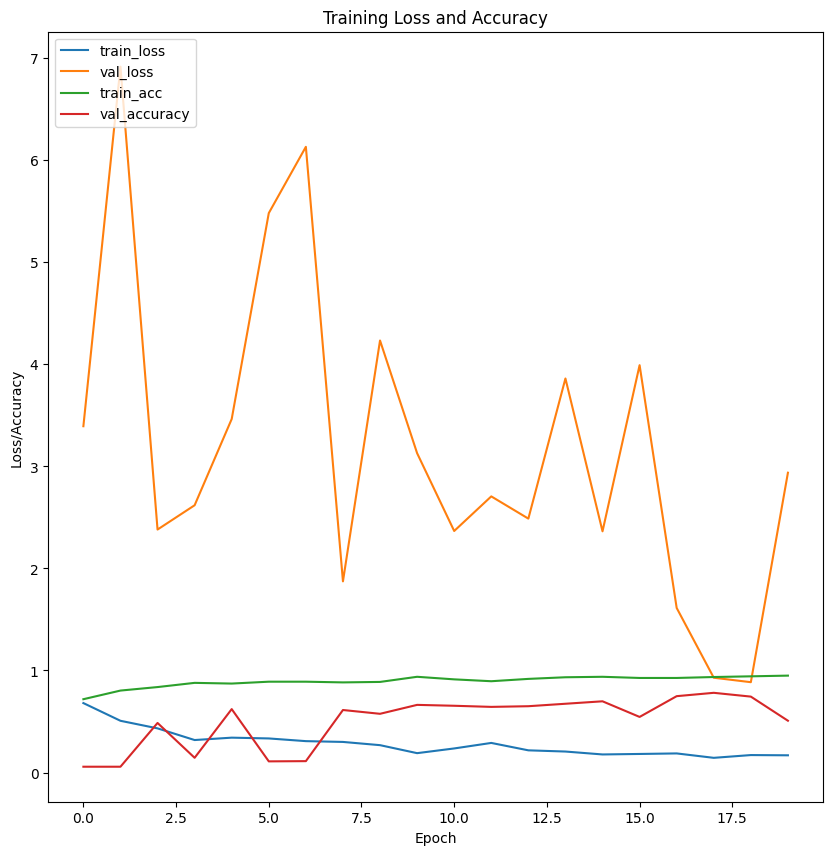

In [17]:
plt.figure(figsize=(10,10))
N = len(history.history['acc'])
plt.plot(np.arange(0, N), history.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), history.history["acc"], label="train_acc")
plt.plot(np.arange(0, N), history.history["val_acc"], label="val_accuracy")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="upper left")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
[[0. 0. 1.]]
Пациент с пневмонией... подхватил всякого разного


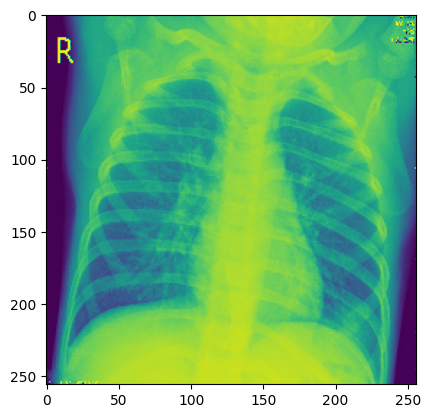

In [19]:
test_image_viral = tf.keras.preprocessing.image.load_img("./static/images/X-ray/test/Viral Pneumonia/VIRUS-262135-0001.jpeg", target_size=(256, 256), color_mode='grayscale')

plt.imshow(test_image_viral)

X = tf.keras.preprocessing.image.img_to_array(test_image_viral)
X = np.expand_dims(X, axis = 0)

prediction = np.vstack([X])

result = deep_model.predict(prediction)

print(result)

arg_max_result = np.argmax(result)

if arg_max_result == 0 :
    print("Пациент с ковидлой")
elif arg_max_result == 1 :
    print("Пациент здорового на вид рентгена")
elif arg_max_result == 2 :
    print("Пациент с пневмонией... подхватил всякого разного")

## Очередная попытка подключить Cuda

In [20]:
!nvidia-smi

!nvcc --version

Sat Apr 19 11:03:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.61                 Driver Version: 572.61         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P5             22W /   40W |       0MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Глубокое обучение на основе PyTorch

In [21]:
import torch 
import torch.nn.functional as F
import IPython.display as ipd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from torch import nn, optim, cuda
from torchvision import transforms, models, datasets
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc
from torch.utils.data import DataLoader, TensorDataset

In [22]:
PIC_SIZE = 256

def load_and_label_images_from_directory(directory, target_size=(256, 256)):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory))

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in sorted(os.listdir(class_path)):
            if file.lower().endswith((".jpg", ".png", ".jpeg", ".bmp")):
                file_path = os.path.join(class_path, file)
                img = cv2.imread(file_path)
                if img is None:
                    continue
                img = cv2.resize(img, target_size)
                images.append(img)
                labels.append(class_name)

    return np.array(images), np.array(labels)

train_dir = "./static/images/X-ray hand/train"
val_dir = "./static/images/X-ray hand/test"

train_images_raw, train_labels_raw = load_and_label_images_from_directory(train_dir)
val_images_raw, val_labels_raw = load_and_label_images_from_directory(val_dir)

_, gauss_train, *_ = preprocess_images(train_images_raw)
_, gauss_val, *_ = preprocess_images(val_images_raw)

# Нормализация и преобразование
train_images_tensor = gauss_train.astype(np.float32) / 255.0
val_images_tensor = gauss_val.astype(np.float32) / 255.0

# Преобразование в grayscale
train_images_tensor = np.mean(train_images_tensor, axis=-1, keepdims=True)
val_images_tensor = np.mean(val_images_tensor, axis=-1, keepdims=True)

# Трансформируем в torch tensors
train_images_tensor = torch.tensor(train_images_tensor).permute(0, 3, 1, 2)
val_images_tensor = torch.tensor(val_images_tensor).permute(0, 3, 1, 2)

# Кодируем метки
label_encoder = LabelEncoder()
train_labels_encoded = torch.tensor(label_encoder.fit_transform(train_labels_raw), dtype=torch.long)
val_labels_encoded = torch.tensor(label_encoder.transform(val_labels_raw), dtype=torch.long)

# Создаем датасеты
train_dataset = TensorDataset(train_images_tensor, train_labels_encoded)
val_dataset = TensorDataset(val_images_tensor, val_labels_encoded)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print(label_encoder.classes_)

['damage' 'no damage']


In [23]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear((PIC_SIZE // 4) * (PIC_SIZE // 4) * 64, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(label_encoder.classes_)
model = SimpleCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loss_history = []
train_acc_history = []

EPOCHS = 30
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / len(train_dataset)

    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)

    acc = correct / len(train_dataset)
    print(f"[{epoch+1}/{EPOCHS}] Loss: {running_loss:.4f} | Accuracy: {acc:.4f}")



[1/30] Loss: 110.2630 | Accuracy: 0.6111
[2/30] Loss: 25.0925 | Accuracy: 0.7778
[3/30] Loss: 15.4051 | Accuracy: 0.7778
[4/30] Loss: 10.8328 | Accuracy: 0.8056
[5/30] Loss: 5.5540 | Accuracy: 0.9722
[6/30] Loss: 2.6731 | Accuracy: 1.0000
[7/30] Loss: 0.6566 | Accuracy: 1.0000
[8/30] Loss: 0.0553 | Accuracy: 1.0000
[9/30] Loss: 0.0144 | Accuracy: 1.0000
[10/30] Loss: 0.0057 | Accuracy: 1.0000
[11/30] Loss: 0.0040 | Accuracy: 1.0000
[12/30] Loss: 0.0024 | Accuracy: 1.0000
[13/30] Loss: 0.0014 | Accuracy: 1.0000
[14/30] Loss: 0.0009 | Accuracy: 1.0000
[15/30] Loss: 0.0007 | Accuracy: 1.0000
[16/30] Loss: 0.0006 | Accuracy: 1.0000
[17/30] Loss: 0.0005 | Accuracy: 1.0000
[18/30] Loss: 0.0005 | Accuracy: 1.0000
[19/30] Loss: 0.0004 | Accuracy: 1.0000
[20/30] Loss: 0.0004 | Accuracy: 1.0000
[21/30] Loss: 0.0004 | Accuracy: 1.0000
[22/30] Loss: 0.0003 | Accuracy: 1.0000
[23/30] Loss: 0.0003 | Accuracy: 1.0000
[24/30] Loss: 0.0003 | Accuracy: 1.0000
[25/30] Loss: 0.0003 | Accuracy: 1.0000
[26/

In [25]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = outputs.argmax(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {correct / total:.4f}")


Validation Accuracy: 1.0000


[[2.0511325e-06 9.9999797e-01]]
Пациент с живой рукой


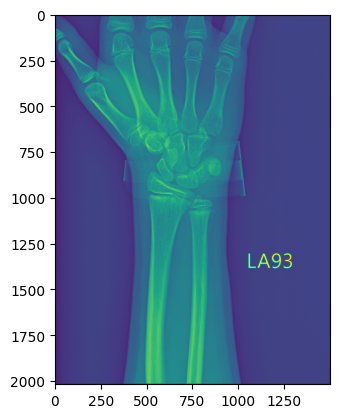

In [29]:
import torchvision.transforms as transforms
from PIL import Image

test_img = Image.open("./static/images/X-ray hand/no damage/4.jpg").convert('L')  # 'L' for grayscale
plt.imshow(test_img)


transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),

])

X = transform(test_img)
X = X.unsqueeze(0)  
X = X.to(device)   

model.eval()
with torch.no_grad():
    outputs = model(X)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    result = probabilities.cpu().numpy()

print(result)
arg_max_result = np.argmax(result)

if arg_max_result == 0:
    print("Пациент сломлен, как и его рука")
elif arg_max_result == 1:
    print("Пациент с живой рукой")

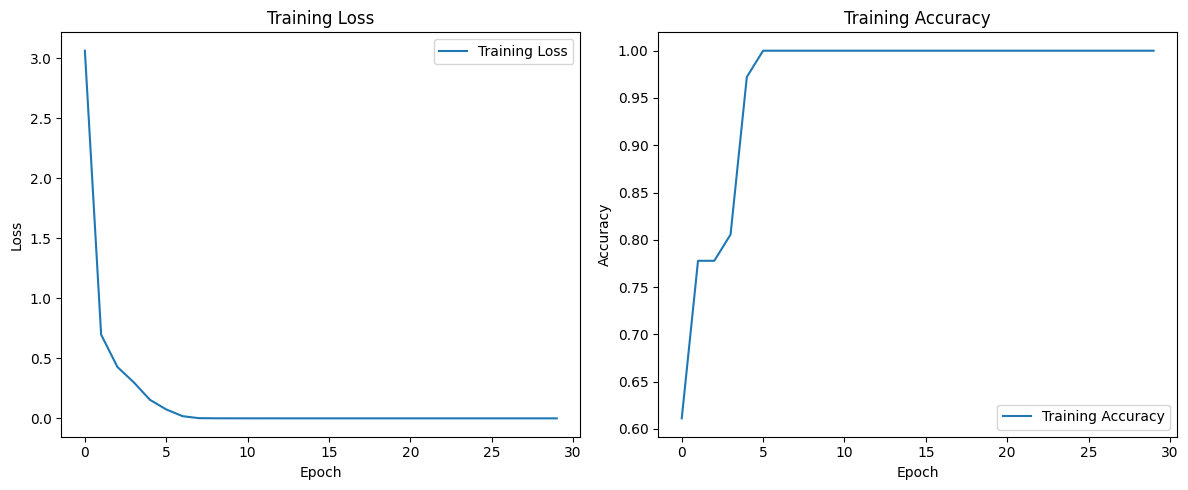

In [30]:
plt.figure(figsize=(12, 5))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

# График Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

plt.tight_layout()
plt.show()